In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from matplotlib import animation
from IPython.display import HTML

## I. Autómata celular unidimensional

Estados $\{0, 1\}$, $L$ celdas con frontera periódica y vecindad de radio $r = 2$. La regla está como su número de Wolfram $R$, con $0 \le R < 2^{32}$: la celda $i$ toma el bit número $v$ de $R$, donde

$$v = 16\,a_{i-2} + 8\,a_{i-1} + 4\,a_i + 2\,a_{i+1} + a_{i+2}.$$

In [2]:
def tabla_regla(regla, r=2):
    return np.array([(regla >> v) & 1 for v in range(2**(2*r + 1))], dtype=np.uint8)

def paso(estado, tabla, r=2):
    v = np.zeros(estado.shape, dtype=int)
    for j in range(-r, r + 1):
        v += np.roll(estado, -j, axis=-1) * 2**(r - j)  
    return tabla[v]

def evolucionar(regla, estado0, pasos, r=2):
    tabla = tabla_regla(regla, r)
    M = np.zeros((pasos + 1, len(estado0)), dtype=np.uint8)
    M[0] = estado0
    for t in range(pasos):
        M[t + 1] = paso(M[t], tabla, r)
    return M

def condicion_central(L):
    x = np.zeros(L, dtype=np.uint8)
    x[L // 2] = 1
    return x

def condicion_aleatoria(L, p=0.5, semilla=0):
    rng = np.random.default_rng(semilla)
    return (rng.random(L) < p).astype(np.uint8)

In [3]:
os.makedirs("figuras", exist_ok=True)

def graficar(M, titulo, archivo=None):
    plt.figure(figsize=(11, 6))
    plt.imshow(M, cmap="binary", interpolation="nearest")
    plt.xlabel("celda $i$", fontsize=14)
    plt.ylabel("tiempo $t$", fontsize=14)
    plt.title(titulo)
    if archivo:

        plt.savefig("figuras/" + archivo, dpi=150, bbox_inches="tight")
        plt.imsave("figuras/bits_" + archivo, M, cmap="binary")  
        
    plt.show()

Configuración: $L = 201$, $T = 100$ pasos, y tambien una sola celda activa en el centro.

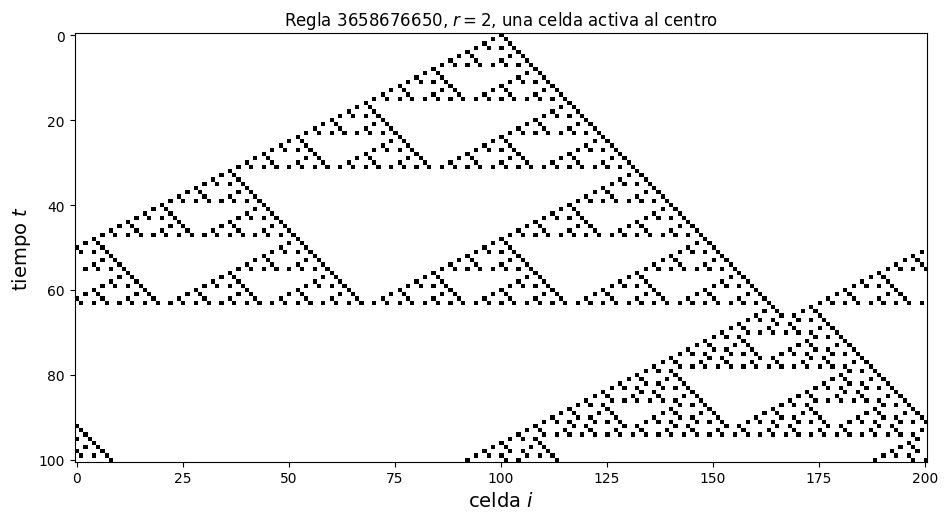

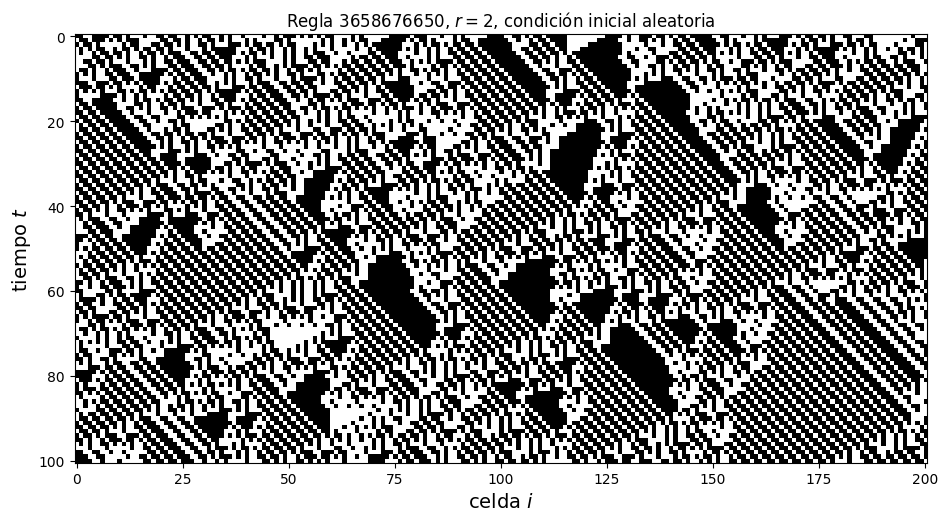

['bits_regla_3658676650.png', 'bits_regla_3658676650_aleatoria.png', 'regla_3658676650.png', 'regla_3658676650_aleatoria.png']


In [4]:
L = 201
T = 100
regla = 3658676650    

M = evolucionar(regla, condicion_central(L), T)
graficar(M, f"Regla {regla}, $r = 2$, una celda activa al centro", f"regla_{regla}.png")

M = evolucionar(regla, condicion_aleatoria(L, 0.5, semilla=3), T)
graficar(M, f"Regla {regla}, $r = 2$, condición inicial aleatoria", f"regla_{regla}_aleatoria.png")

print(sorted(os.listdir("figuras")))

### Exploración de reglas

Con $2^{32}$ reglas no se pueden ver todas aqui, po lo  que exploramos dos familias del NKS escritas como números de Wolfram de radio 2: las totalísticas (el nuevo estado sólo depende de la sum de las 5 celdas, códigos 0 a 63) y algunas elementales de radio 1 (30, 90, 110), en las que las celdas $a_{i\pm 2}$ no influyen.

In [5]:
def totalistica(codigo, r=2):
    return sum(((codigo >> bin(v).count("1")) & 1) << v for v in range(2**(2*r + 1)))

def desde_elemental(regla):
    return sum(((regla >> ((v >> 1) & 7)) & 1) << v for v in range(32))

print("código totalístico 20 ->", totalistica(20))
print("regla elemental 30    ->", desde_elemental(30))

código totalístico 20 -> 1771476584
regla elemental 30    -> 66847740


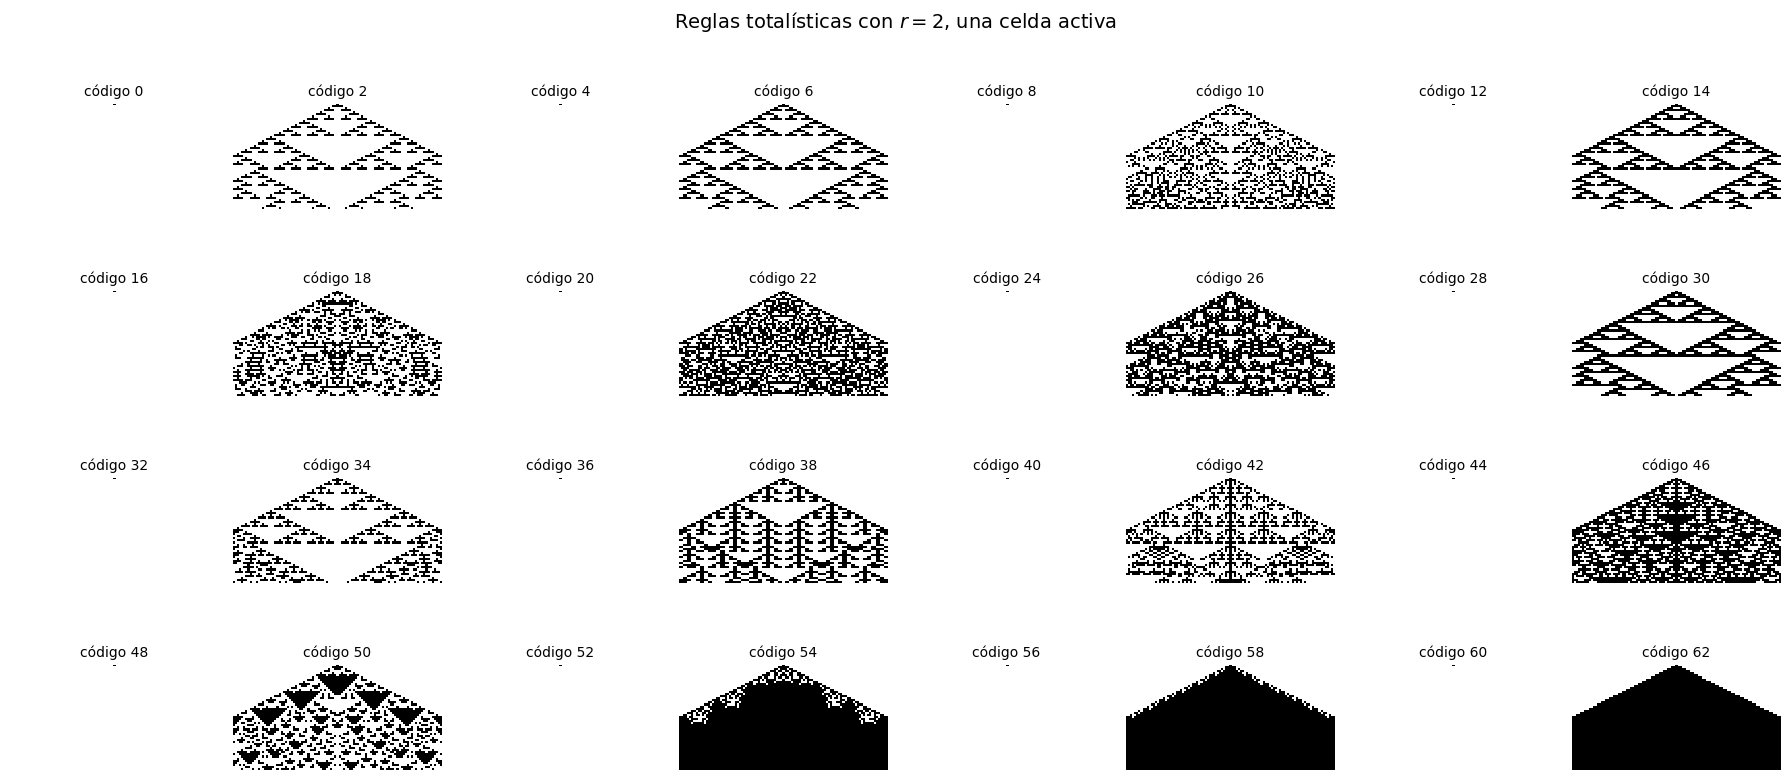

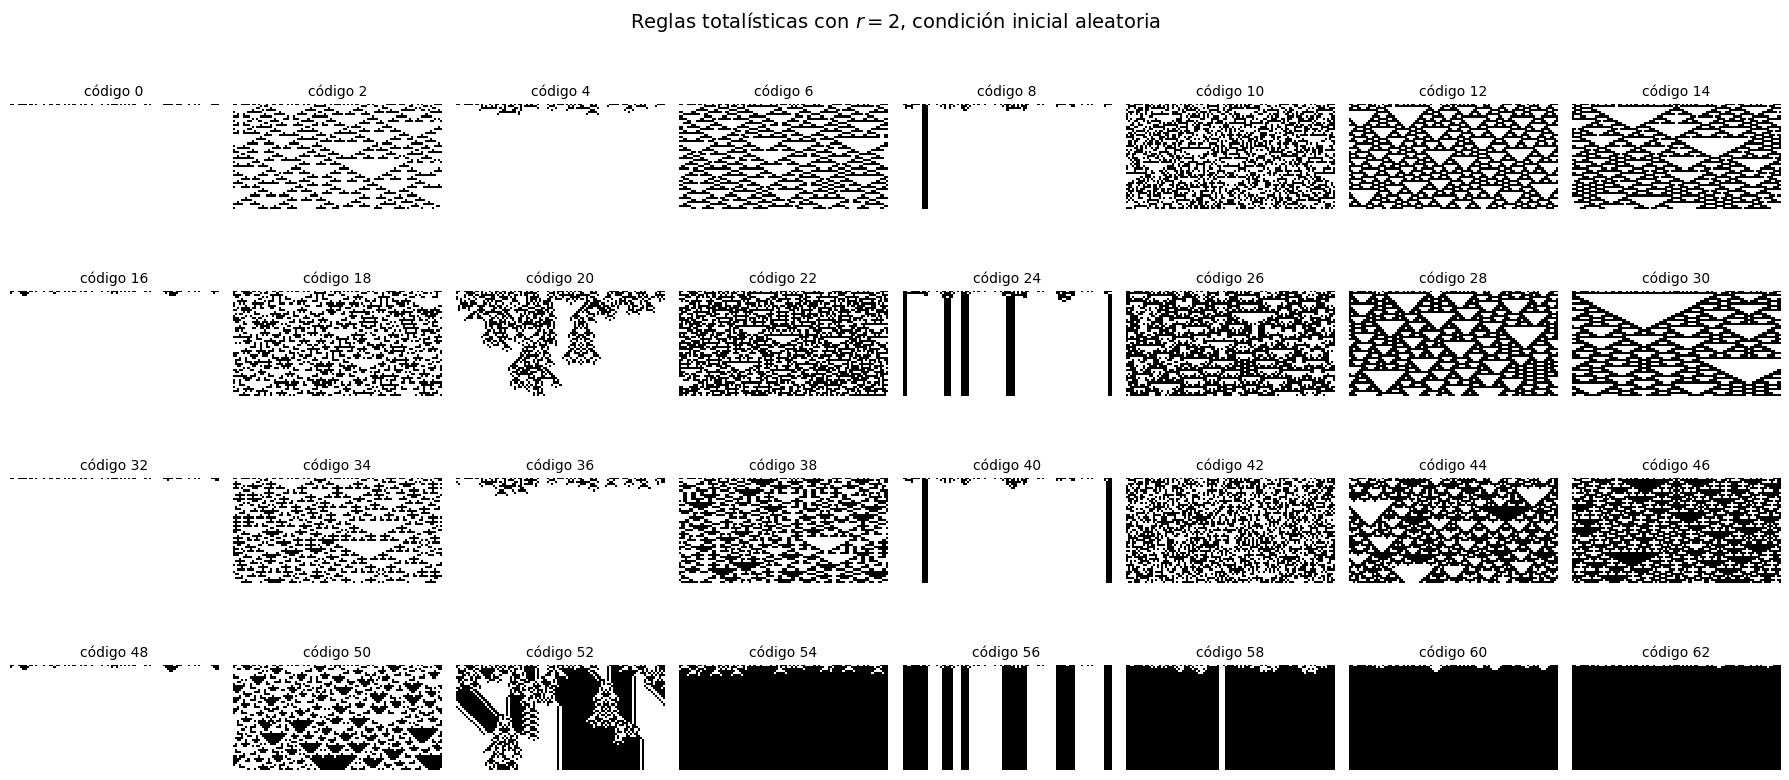

In [6]:
#Códigos pares  
codigos = list(range(0, 64, 2))
L, T = 101, 50
x_aleatoria = condicion_aleatoria(L, 0.5, semilla=3)

for x0, nombre, archivo in [(condicion_central(L), "una celda activa", "totalisticas_central.png"),
                            (x_aleatoria, "condición inicial aleatoria", "totalisticas_aleatoria.png")]:
    fig, ejes = plt.subplots(4, 8, figsize=(18, 8.5))
    for eje, c in zip(ejes.flat, codigos):
        eje.imshow(evolucionar(totalistica(c), x0, T), cmap="binary", interpolation="nearest")
        eje.set_title(f"código {c}", fontsize=10)
        eje.axis("off")
    plt.suptitle(f"Reglas totalísticas con $r = 2$, {nombre}", fontsize=14)
    plt.tight_layout()
    plt.savefig("figuras/" + archivo, dpi=120)
    plt.show()

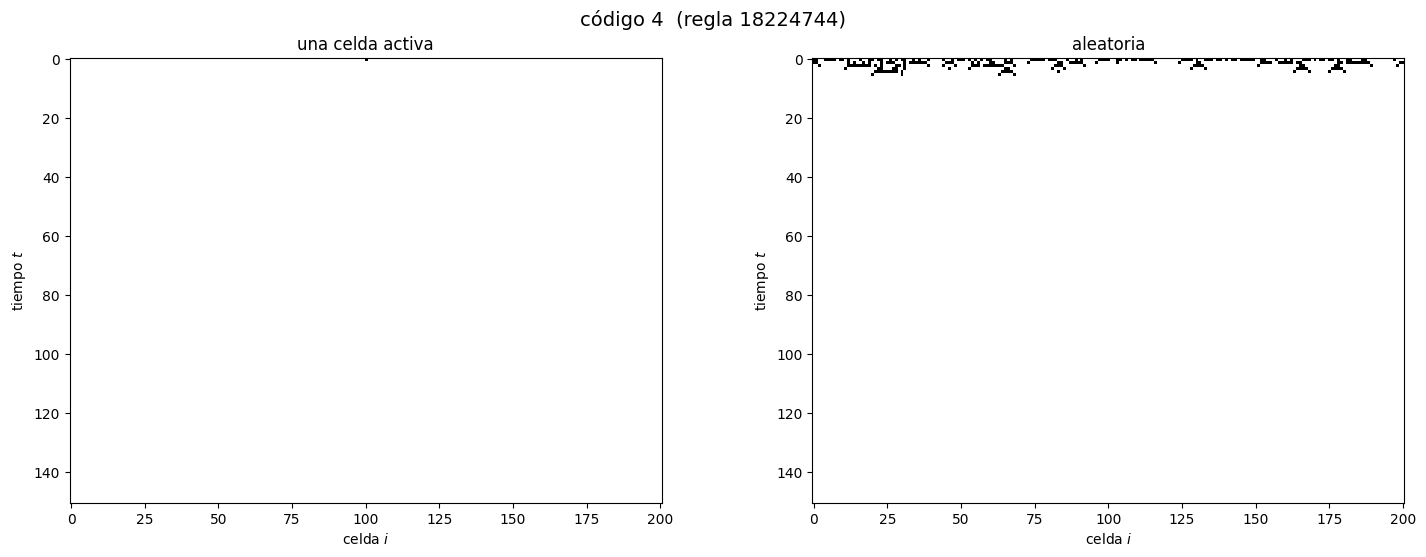

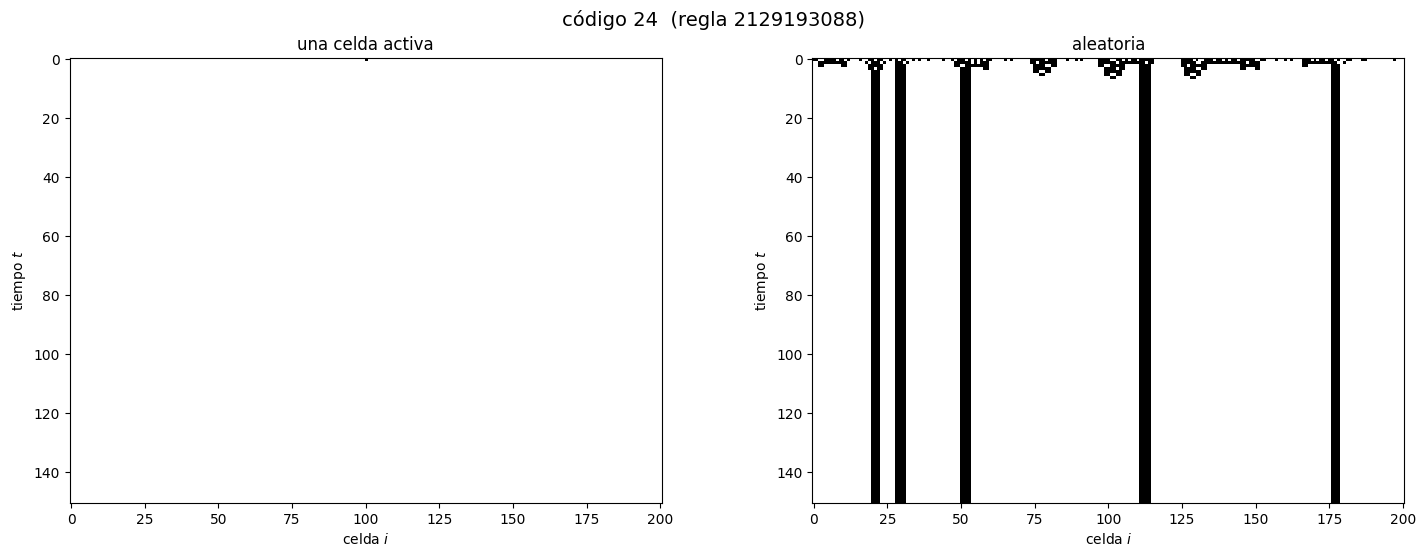

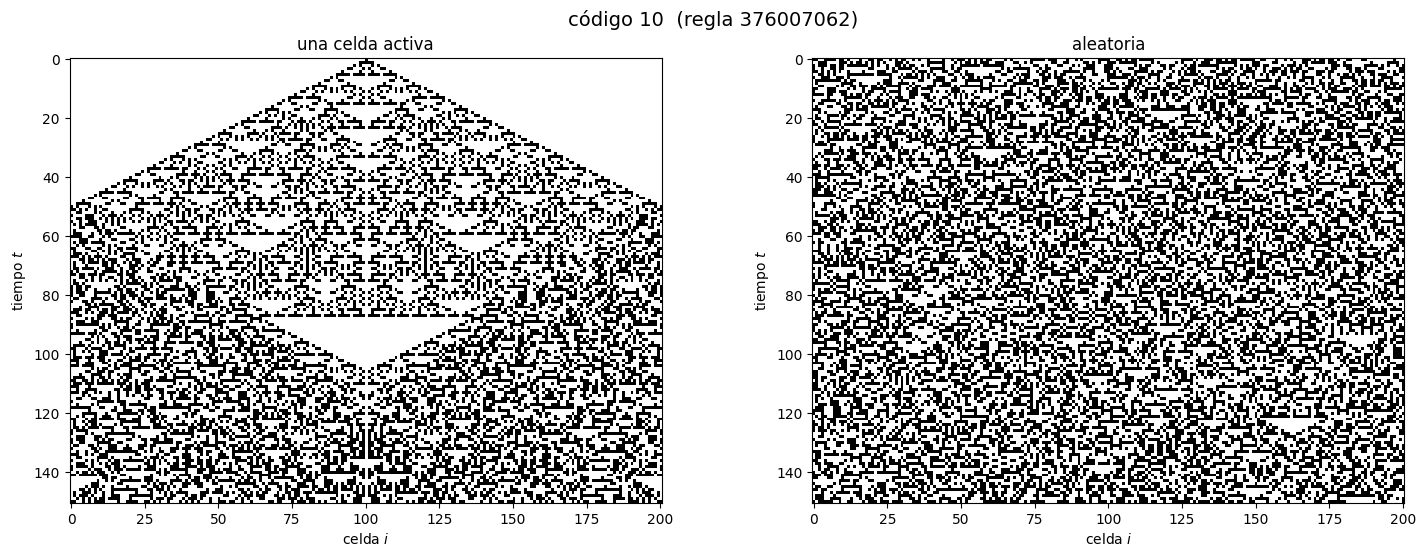

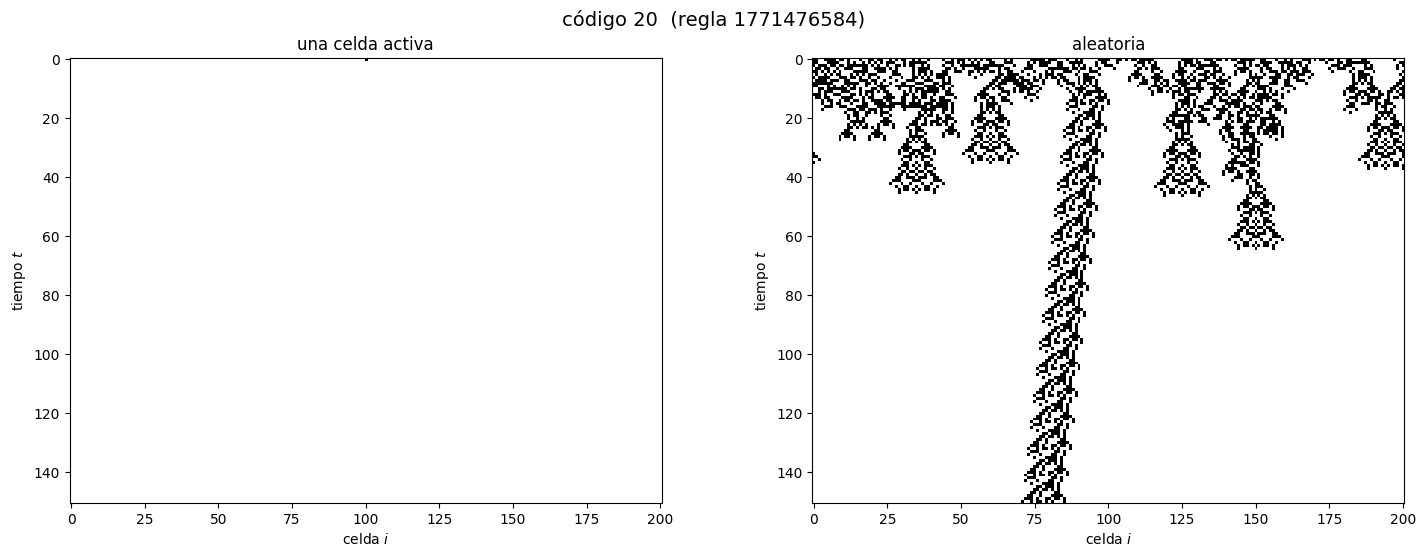

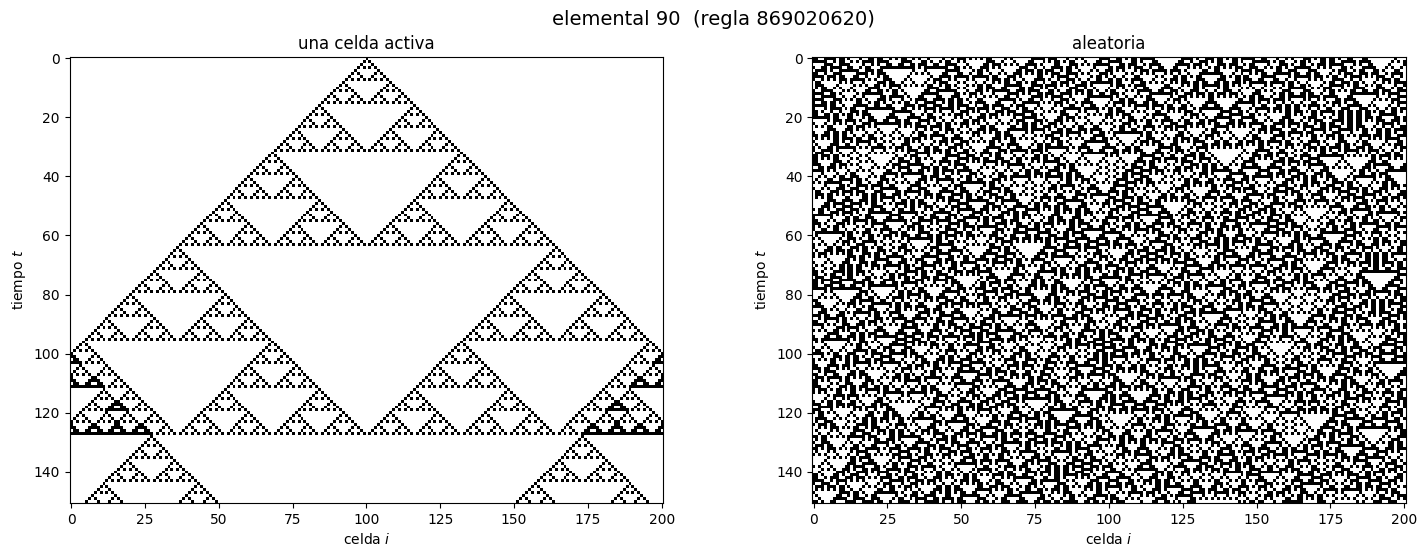

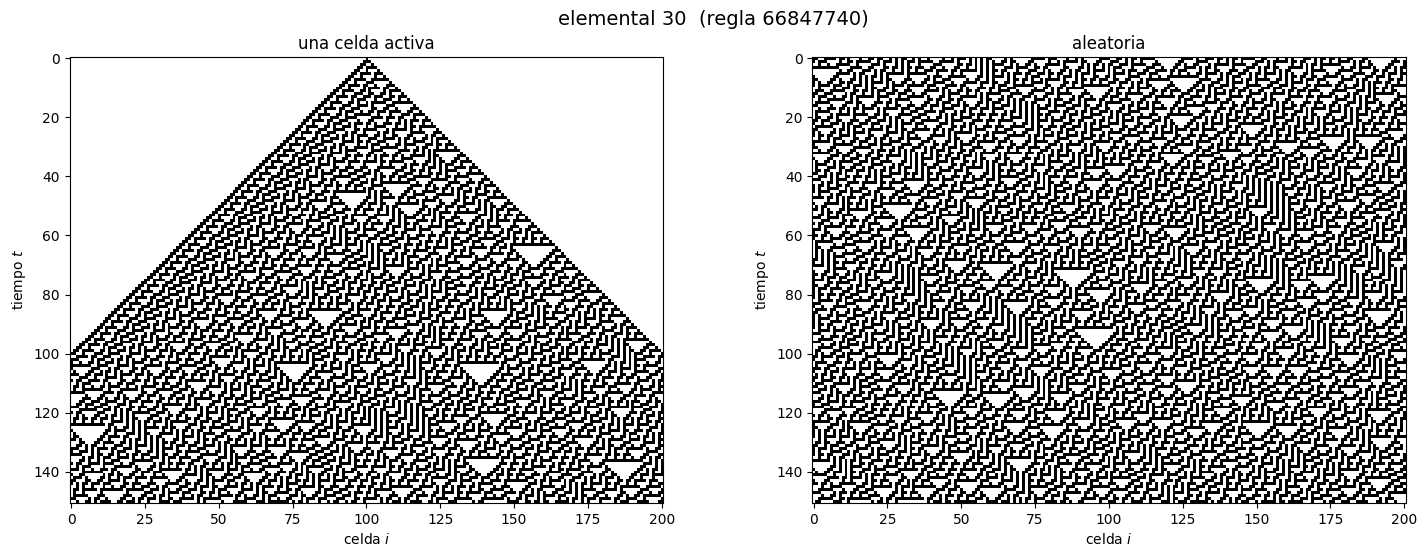

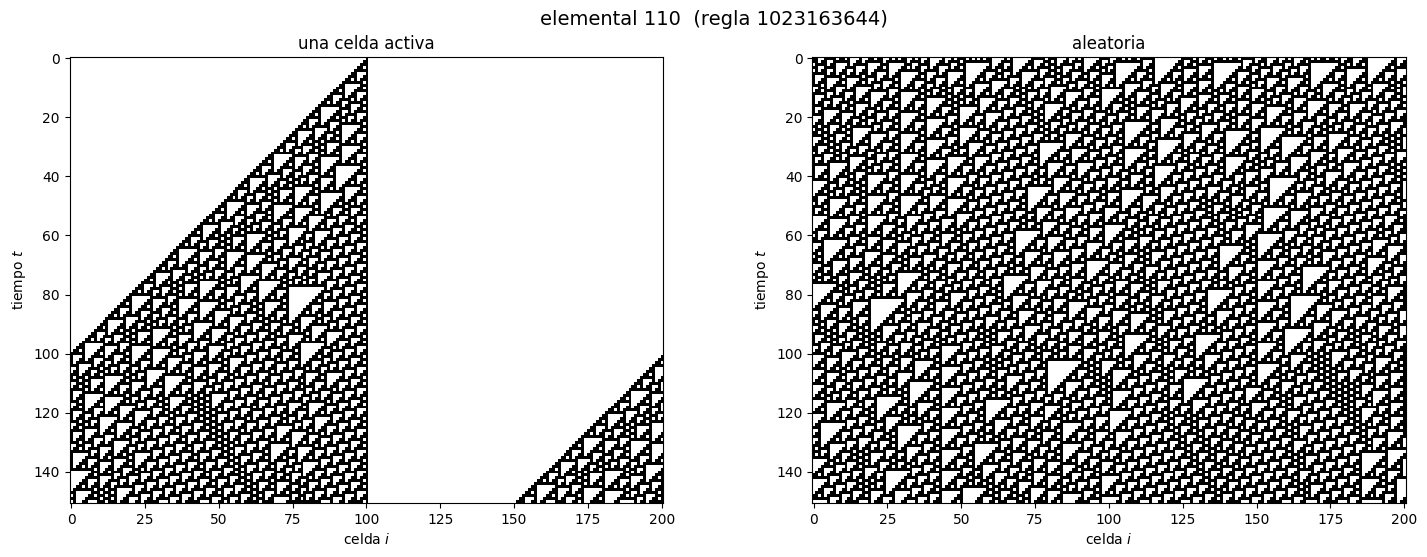

In [7]:
seleccion = [("código 4", totalistica(4)),
             ("código 24", totalistica(24)),
             ("código 10", totalistica(10)),
             ("código 20", totalistica(20)),
             ("elemental 90", desde_elemental(90)),
             ("elemental 30", desde_elemental(30)),
             ("elemental 110", desde_elemental(110))]

L, T = 201, 150
x_aleatoria = condicion_aleatoria(L, 0.5, semilla=3)

for nombre, regla in seleccion:
    fig, ejes = plt.subplots(1, 2, figsize=(15, 5.5))
    for eje, x0, titulo in zip(ejes, [condicion_central(L), x_aleatoria], ["una celda activa", "aleatoria"]):
        eje.imshow(evolucionar(regla, x0, T), cmap="binary", interpolation="nearest")
        eje.set_title(titulo)
        eje.set_xlabel("celda $i$")
        eje.set_ylabel("tiempo $t$")
    plt.suptitle(f"{nombre}  (regla {regla})", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"figuras/regla_{regla}.png", dpi=120)
    plt.show()

Desde una sola celda casi no se ve nada (se puede apreciar en los múltiplos de 4), así que conviene ver la condición aleatoria, donde salen las cuatro clases de Wolfram. Algunas reglas lo apagan  rápido (0, 4, 16, 32, 36, 48) o lo llenan de unos (54, 60, 62), y eso es la clase 1. El 8, 24, 40 y 56 dejan franjas verticales fijas (clase 2). Desde una celda, los códigos 2, 6, 14, 30 y 34 y la regla 90 hacen triángulos tipo Sierpinski.

Los códigos 10, 18, 22, 26, 42 y 46 y la regla 30 se ven aleatorios y nunca se estabilizan, y el 12, 28 y 44 llenan todo de triángulos sin orden (clase 3). La regla 3658676650, azarosament selecccionada, queda en medio. 

El código 20 llama la atención: casi todo desaparce antes de $t \approx 60$, pero queda una estructura que avanza a la izquierda (clase 4). El 52 se parece un poco, con paredes y estructuras que chocan. La regla 110, el ejemplo de clase 4 que usa Wolfram, mezcla zonas regulares con estructuras que se mueven y chocan.

## Análisis dinámico

### a) Gráfica de transición de estados y atractores (versión finite)

Configuración: $L = 9$, es decir las $2^9 = 512$ configuraciones posibles, frontera periódica y la regla totalística de código 20 (número de Wolfram 1771476584).

In [8]:
L = 9
N = 2**L
regla = totalistica(20)

estados = (np.arange(N)[:, None] >> np.arange(L - 1, -1, -1)) & 1
pesos = 2**np.arange(L - 1, -1, -1)
siguiente = paso(estados, tabla_regla(regla)) @ pesos

G = nx.DiGraph()
G.add_nodes_from(range(N))
G.add_edges_from((c, int(siguiente[c])) for c in range(N))
print("Nodos:", G.number_of_nodes(), "  Aristas:", G.number_of_edges())

Nodos: 512   Aristas: 512


In [9]:
def a_bits(c):
    return format(c, f"0{L}b")

cuencas = []
for comp in nx.weakly_connected_components(G):
    ciclo = next(nx.simple_cycles(G.subgraph(comp)))
    cuencas.append((comp, ciclo))
cuencas.sort(key=lambda cc: (-len(cc[0]), len(cc[1]), min(cc[1])))

tabla = pd.DataFrame({"Atractor": range(1, len(cuencas) + 1),
                      "Periodo": [len(ciclo) for comp, ciclo in cuencas],
                      "Tamaño de cuenca": [len(comp) for comp, ciclo in cuencas],
                      "Una configuración del ciclo": [a_bits(min(ciclo)) for comp, ciclo in cuencas]})

print("Número de atractores:", len(tabla))
print("Suma de los tamaños de cuenca:", tabla["Tamaño de cuenca"].sum(), "de", N)
tabla.set_index("Atractor")

Número de atractores: 22
Suma de los tamaños de cuenca: 512 de 512


,Periodo,Tamaño de cuenca,Una configuración del ciclo
Atractor,,,
1,1,182,000000000
2,22,28,000001011
3,22,28,000001101
4,22,28,000010011
5,22,28,000010111
6,22,28,000011010
7,22,28,000011101
8,22,28,000101001
9,22,28,000110100


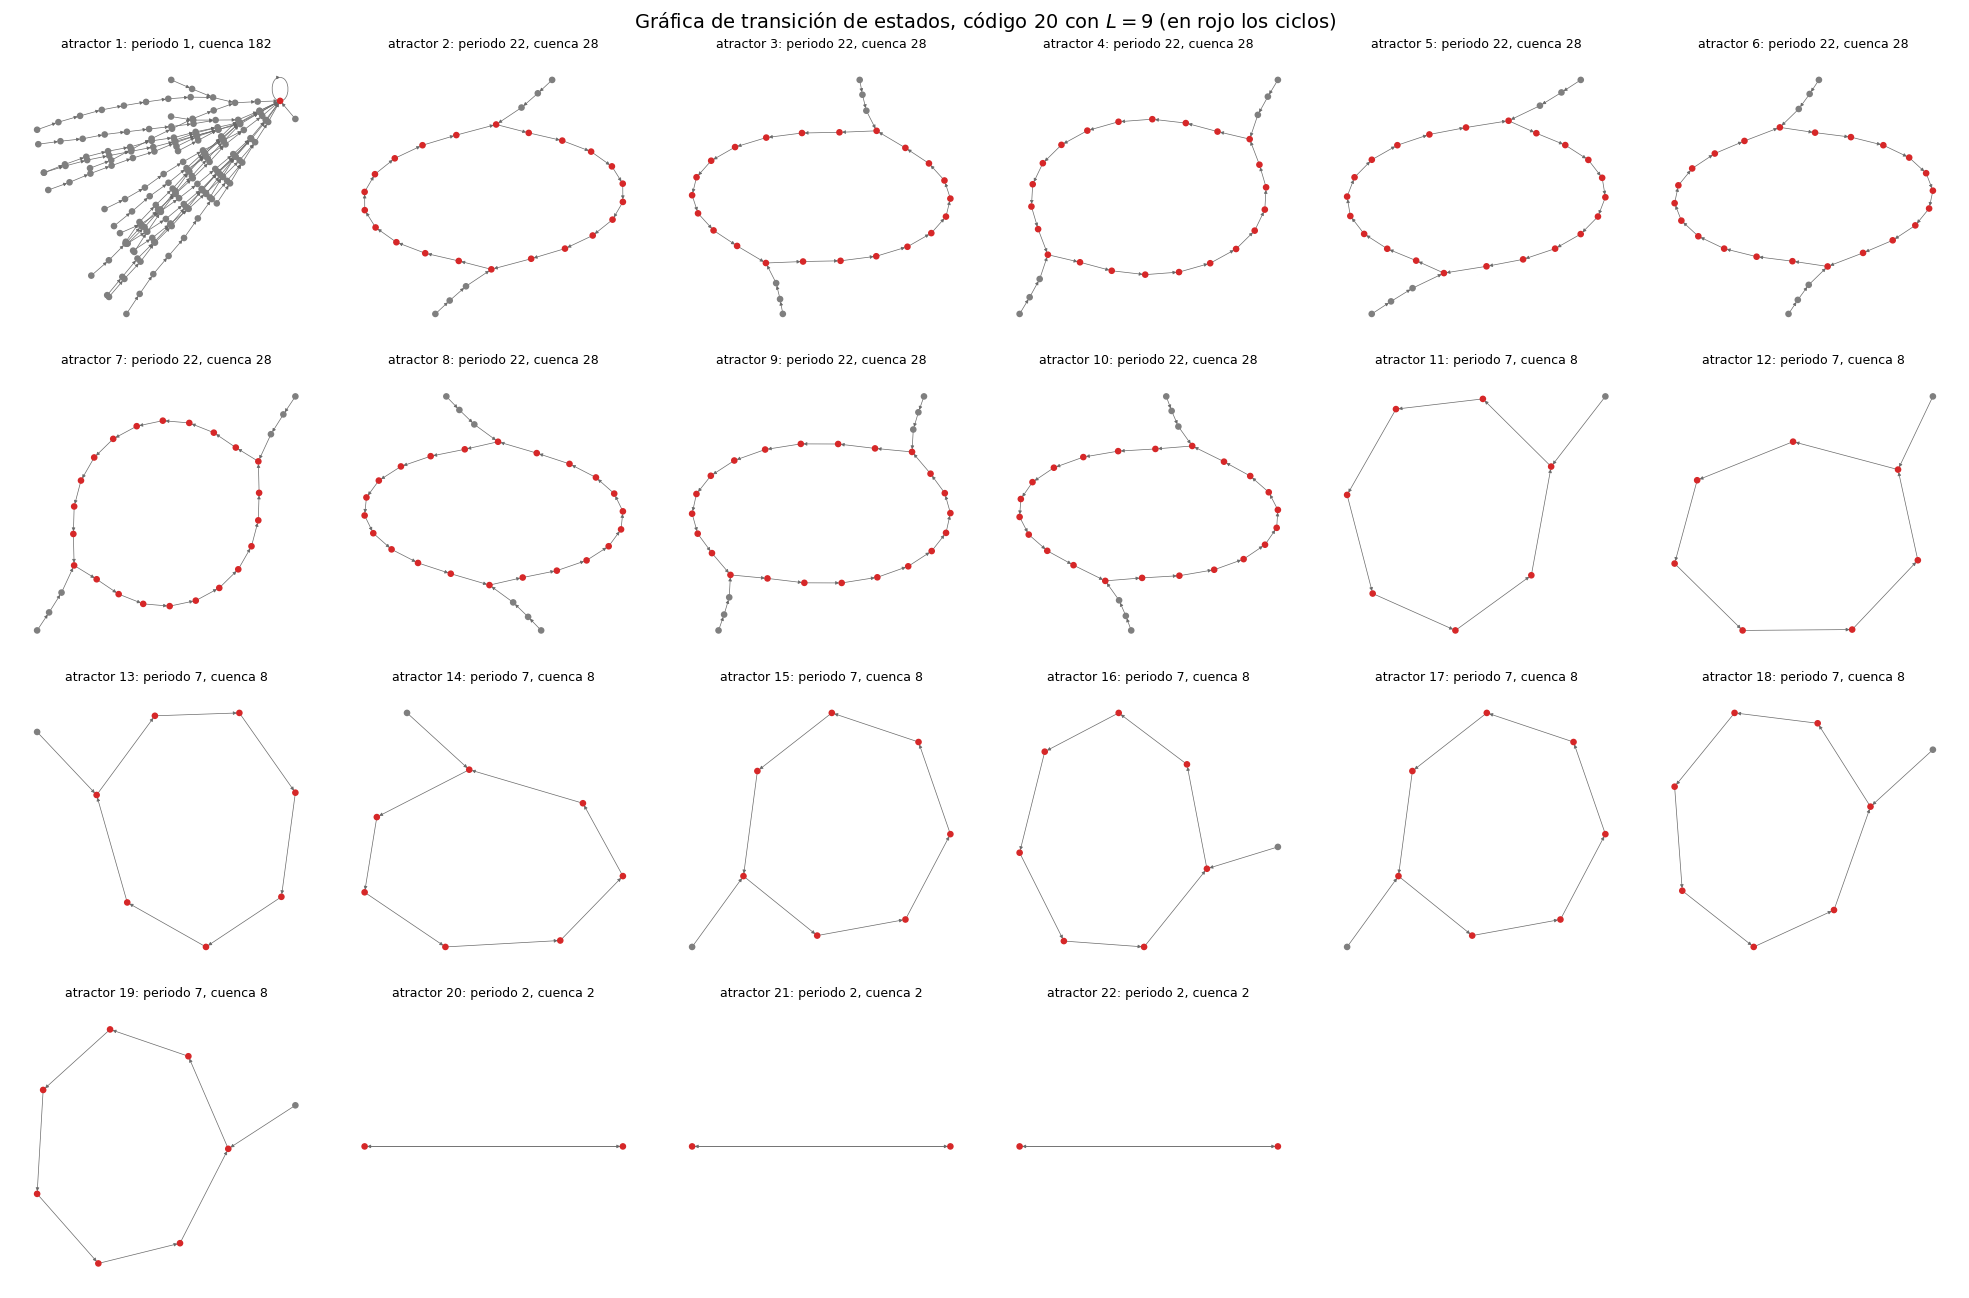

In [10]:
columnas = 6
renglones = int(np.ceil(len(cuencas) / columnas))
fig, ejes = plt.subplots(renglones, columnas, figsize=(3.3*columnas, 3.3*renglones))

for k, (eje, (comp, ciclo)) in enumerate(zip(ejes.flat, cuencas)):
    H = G.subgraph(comp)
    pos = nx.kamada_kawai_layout(H) if len(comp) > 2 else nx.circular_layout(H)
    colores = ["tab:red" if c in ciclo else "tab:gray" for c in H.nodes()]
    nx.draw(H, pos, ax=eje, node_size=14, node_color=colores, width=0.5,
            arrowsize=5, edge_color="dimgray")
    eje.set_title(f"atractor {k + 1}: periodo {len(ciclo)}, cuenca {len(comp)}", fontsize=9)
for eje in ejes.flat[len(cuencas):]:
    eje.axis("off")

plt.suptitle("Gráfica de transición de estados, código 20 con $L = 9$ (en rojo los ciclos)", fontsize=14)
plt.tight_layout()
plt.savefig("figuras/transiciones_L9.png", dpi=150)
plt.show()

## II. Elección: Juego de la vida

Malla de $N \times N$ con frontera periódica, vecindad de Moore y regla B3/S23 (una celda muerta nace con exactamente 3 vecinas vivas, una viva sobrevive con 2 o 3).

In [11]:
def contar_vecinos(M):
    return sum(np.roll(np.roll(M, i, axis=0), j, axis=1)
               for i in (-1, 0, 1) for j in (-1, 0, 1) if (i, j) != (0, 0))

def paso_vida(M):
    v = contar_vecinos(M)
    return ((v == 3) | ((M == 1) & (v == 2))).astype(np.uint8)

def correr_vida(M0, generaciones):
    historia = [M0]
    for _ in range(generaciones):
        historia.append(paso_vida(historia[-1]))
    return np.array(historia)

Configuración: $N = 20$ con un parpadeador, un blque y un planeador

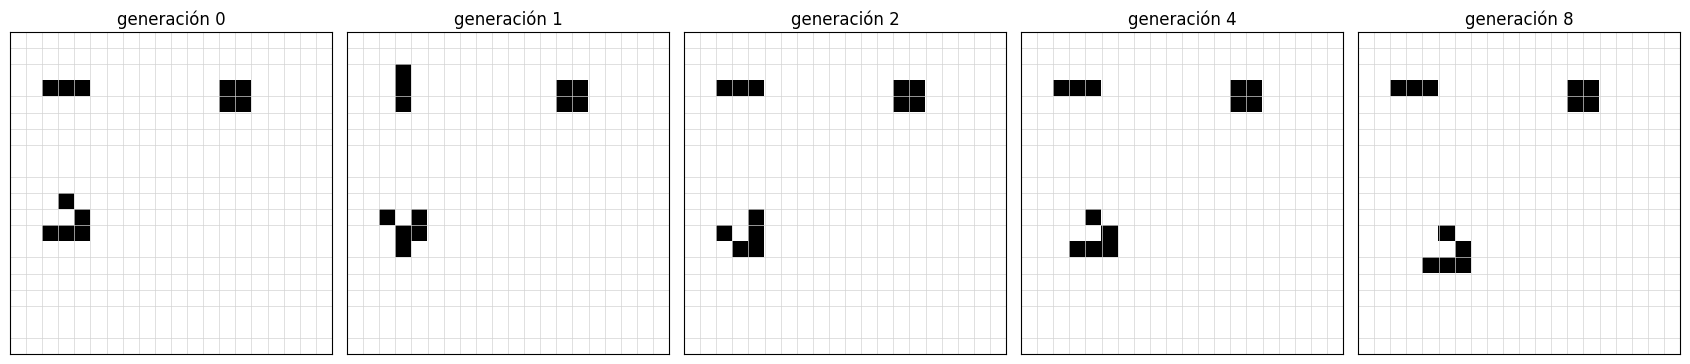

In [12]:
N = 20
M0 = np.zeros((N, N), dtype=np.uint8)
M0[3, 2:5] = 1  # parpadeador
M0[3:5, 13:15] = 1  # bloque
M0[10, 3] = 1   # planeador
M0[11, 4] = 1
M0[12, 2:5] = 1

H = correr_vida(M0, 8)

fig, ejes = plt.subplots(1, 5, figsize=(17, 4))
for eje, g in zip(ejes, [0, 1, 2, 4, 8]):
    eje.imshow(H[g], cmap="binary", interpolation="nearest")
    eje.set_xticks(np.arange(-0.5, N, 1), minor=True)
    eje.set_yticks(np.arange(-0.5, N, 1), minor=True)
    eje.grid(which="minor", color="lightgray", linewidth=0.5)
    eje.tick_params(which="both", length=0, labelbottom=False, labelleft=False)
    eje.set_title(f"generación {g}")
plt.tight_layout()
plt.savefig("figuras/vida_patrones.png", dpi=120)
plt.show()

Configuración: $N = 100$, condición inicial aleatoria con 30% de celdas vivas y  400 generaciones.

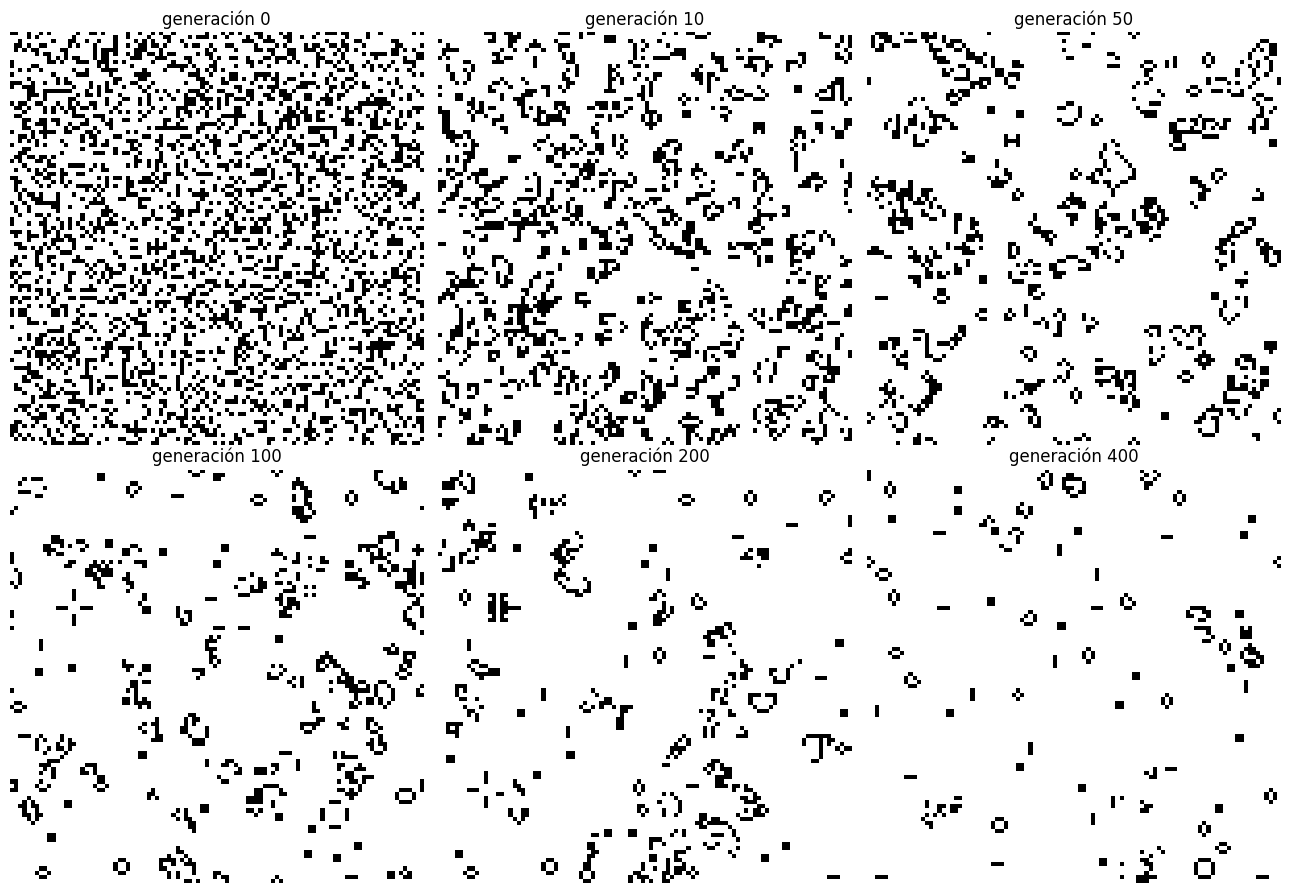

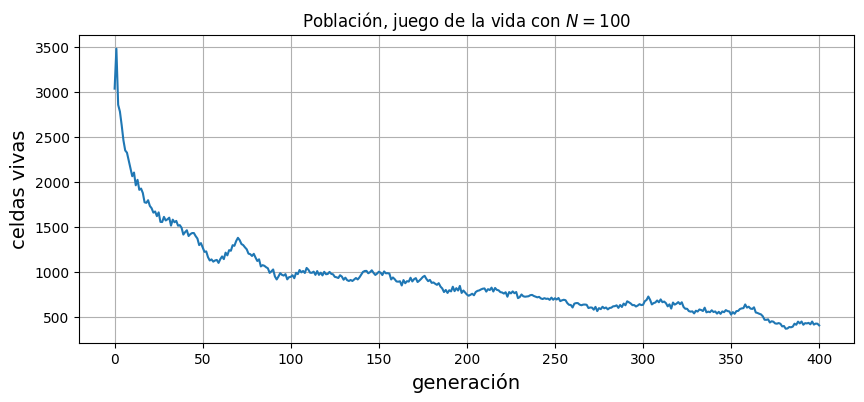

In [13]:
N = 100
gens = 400
rng = np.random.default_rng(3)
M0 = (rng.random((N, N)) < 0.3).astype(np.uint8)
H = correr_vida(M0, gens)

instantes = [0, 10, 50, 100, 200, 400]
fig, ejes = plt.subplots(2, 3, figsize=(13, 9))
for eje, g in zip(ejes.flat, instantes):
    eje.imshow(H[g], cmap="binary", interpolation="nearest")
    eje.set_title(f"generación {g}")
    eje.axis("off")
plt.tight_layout()
plt.savefig("figuras/vida_aleatoria.png", dpi=120)
plt.show()

poblacion = H.sum(axis=(1, 2))
plt.figure(figsize=(10, 4))
plt.plot(poblacion)
plt.xlabel("generación", fontsize=14)
plt.ylabel("celdas vivas", fontsize=14)
plt.title("Población, juego de la vida con $N = 100$")
plt.grid()
plt.show()

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
imagen = ax.imshow(H[0], cmap="binary", interpolation="nearest")
ax.axis("off")

def actualizar(k):
    imagen.set_data(H[k])
    ax.set_title(f"generación {k}")
    return [imagen]

ani = animation.FuncAnimation(fig, actualizar, frames=range(0, 200, 2), interval=100)
plt.close()
HTML(ani.to_jshtml())